In [2]:
# === INSTALAÇÃO (rode uma vez; depois reinicie o kernel) ===
!pip install -U "pip<25"
!pip install -U "numpy<2.0" pandas matplotlib scikit-learn joblib
!pip install -U xgboost
!pip install -U "tensorflow==2.15.0" "keras==2.15.0"


     ---------------------------------------- 1.8/1.8 MB 8.3 MB/s eta 0:00:00


ERROR: To modify pip, please run the following command:
C:\Users\saulo\anaconda3\python.exe -m pip install -U pip<25


  Using cached numpy-1.26.4-cp39-cp39-win_amd64.whl (15.8 MB)


In [3]:
!pip install --user -U "numpy<2.0" pandas matplotlib scikit-learn joblib xgboost "tensorflow==2.15.0" "keras==2.15.0"


  Using cached numpy-1.26.4-cp39-cp39-win_amd64.whl (15.8 MB)


In [6]:
import sys
import numpy as np
import pandas as pd
import tensorflow as tf

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("TensorFlow:", tf.__version__)

# Keras version: TF 2.15 pode não expor tf.keras.__version__
try:
    import keras
    print("Keras:", keras.__version__)
except Exception:
    # fallback seguro
    print("Keras: (standalone keras não encontrado; usando tf.keras)")

# Teste 1: leitura do seu CSV
import os
path = "Processed_Normalized_Data.csv"
print("CSV existe?", os.path.exists(path))
if os.path.exists(path):
    df = pd.read_csv(path)
    print("CSV shape:", df.shape)
    print("Dtypes (top):")
    print(df.dtypes.head(10))

# Teste 2: XGBoost aceita multioutput direto?
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor

X_demo = np.random.randn(10, 5)
y_demo = np.random.randn(10, 3)

try:
    m = XGBRegressor(objective="reg:squarederror", n_estimators=10, random_state=0)
    m.fit(X_demo, y_demo)
    pred = m.predict(X_demo)
    print("XGBRegressor multioutput: OK | pred shape:", pred.shape)
except Exception as e:
    print("XGBRegressor multioutput: FALHOU ->", type(e).__name__, str(e)[:200])
    m2 = MultiOutputRegressor(XGBRegressor(objective="reg:squarederror", n_estimators=10, random_state=0))
    m2.fit(X_demo, y_demo)
    pred2 = m2.predict(X_demo)
    print("MultiOutputRegressor fallback: OK | pred shape:", pred2.shape)

# Teste 3: TensorFlow básico
a = tf.constant([1.0, 2.0, 3.0])
print("TF ok, soma:", tf.reduce_sum(a).numpy())


Python: 3.9.13
NumPy: 1.24.4
Pandas: 2.3.3
TensorFlow: 2.15.0
Keras: 2.15.0
CSV existe? True
CSV shape: (24, 33)
Dtypes (top):
Year                      int64
Legislative             float64
Judiciary               float64
Essential to Justice    float64
Administration          float64
National Defense        float64
Public Safety           float64
Foreign Relations       float64
Social Assistance       float64
Security                float64
dtype: object
XGBRegressor multioutput: OK | pred shape: (10, 3)
TF ok, soma: 6.0


In [ ]:
!conda install -y -c conda-forge "numexpr>=2.8.4" "bottleneck>=1.3.6"


In [1]:
!pip install -U "numexpr>=2.8.4" "bottleneck>=1.3.6"


     -------------------------------------- 145.0/145.0 kB 2.2 MB/s eta 0:00:00
     ---------------------------------------- 112.1/112.1 kB ? eta 0:00:00
  Attempting uninstall: numexpr
    Found existing installation: numexpr 2.8.3
    Uninstalling numexpr-2.8.3:
      Successfully uninstalled numexpr-2.8.3
  Attempting uninstall: bottleneck
    Found existing installation: Bottleneck 1.3.5
    Uninstalling Bottleneck-1.3.5:
      Successfully uninstalled Bottleneck-1.3.5


In [2]:
import pandas as pd, numexpr, bottleneck
print("pandas:", pd.__version__)
print("numexpr:", numexpr.__version__)
print("bottleneck:", bottleneck.__version__)


pandas: 2.3.3
numexpr: 2.10.2
bottleneck: 1.5.0



Python: 3.9.13
NumPy: 1.24.4
Pandas: 2.3.3
TensorFlow: 2.15.0
Keras: 2.15.0


Statistics of original data (inputs):
       Legislative     Judiciary  Essential to Justice  Administration  \
mean -1.110223e-16  1.665335e-16          2.220446e-16    2.868076e-16   
std   1.021508e+00  1.021508e+00          1.021508e+00    1.021508e+00   
min  -2.049252e+00 -1.463593e+00         -1.664928e+00   -1.486595e+00   
max   1.634838e+00  1.772988e+00          1.867415e+00    1.640225e+00   

      National Defence  Public Safety  Foreign Relations  Social Assistance  \
mean     -1.942890e-16  -1.110223e-16      -7.401487e-17       3.700743e-17   
std       1.021508e+00   1.021508e+00       1.021508e+00       1.021508e+00   
min      -1.071809e+00  -1.380108e+00      -1.534381e+00      -7.897149e-01   
max       1.678043e+00   2.172059e+00       1.679012e+00       3.560490e+00   

      Social Security        Health  ...   Agriculture  Agrarian Organisation  \
mean    -1.850372e-16 -7.401487e-17

C:\Users\saulo\AppData\Local\Temp\ipykernel_85132\1535856587.py:466: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([X[col], synX[col]], labels=["Original", "Synthetic"])
C:\Users\saulo\AppData\Local\Temp\ipykernel_85132\1535856587.py:466: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([X[col], synX[col]], labels=["Original", "Synthetic"])
C:\Users\saulo\AppData\Local\Temp\ipykernel_85132\1535856587.py:466: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([X[col], synX[col]], labels=["Original", "Synthetic"])
C:\Users\saulo\AppData\Local\Temp\ipykernel_85132\1535856587.py:466: Matplotlib

C:\Users\saulo\AppData\Local\Temp\ipykernel_85132\1535856587.py:466: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([X[col], synX[col]], labels=["Original", "Synthetic"])
C:\Users\saulo\AppData\Local\Temp\ipykernel_85132\1535856587.py:466: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([X[col], synX[col]], labels=["Original", "Synthetic"])
C:\Users\saulo\AppData\Local\Temp\ipykernel_85132\1535856587.py:486: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([y[col], synY[col]], labels=["Original", "Synthetic"])
C:\Users\saulo\AppData\Local\Temp\ipykernel_85132\1535856587.py:486: Matplotlib

Number of original observations: 24
Number of synthetic observations: 1048
Final number of observations after concatenation: 1072

Consolidated Metrics (K-Fold on augmented dataset — internal validation):
Mean General MSE: 0.03526115044951439
Mean General R²: 0.9657719135284424
Mean General Adjusted R²: 0.9603919422363842
--- GDP growth Metrics ---
Mean MSE: 0.03569317373119689
Mean RMSE: 0.18436488275536708
Mean R²: 0.9646504636254786
Mean Adjusted R²: 0.9590961360627868
--- Inflation Metrics ---
Mean MSE: 0.03434595657635026
Mean RMSE: 0.1829320981904952
Mean R²: 0.9652968613974069
Mean Adjusted R²: 0.9598396484105892
--- Gini index Metrics ---
Mean MSE: 0.03574432305576712
Mean RMSE: 0.18208384613745127
Mean R²: 0.9673684058769512
Mean Adjusted R²: 0.9622400310363867


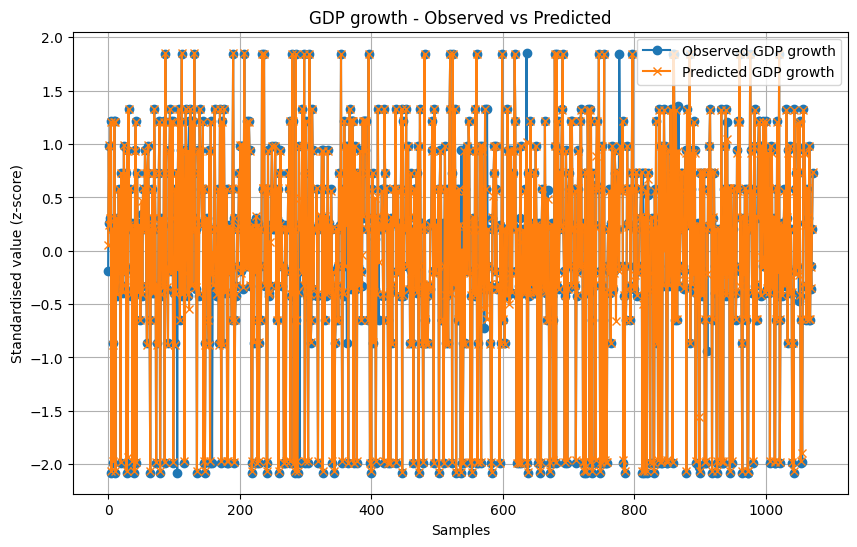

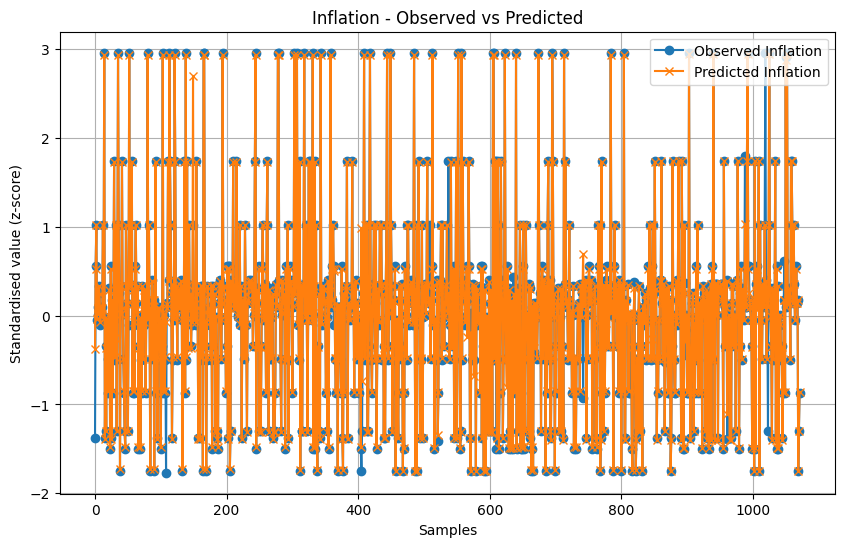

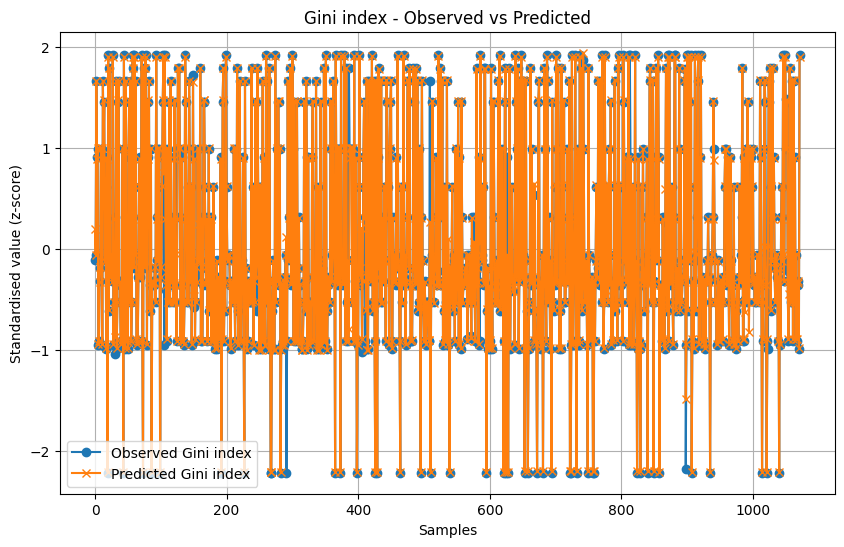

Comparison Table - primeiras 5 observações:
   Observed GDP growth  Observed Inflation  Observed Gini index  \
0            -0.193032           -1.378780            -0.107174   
1             0.979753            0.556737            -0.065007   
2             0.256805            1.017266             1.663835   
3             0.309472           -0.051843             0.904831   
4             1.215608            0.093077             0.989165   

   Predicted GDP growth  Predicted Inflation  Predicted Gini index  
0              0.054482            -0.373105              0.194338  
1              0.992722             0.518619             -0.059589  
2              0.243550             1.023038              1.663583  
3              0.302958            -0.037726              0.891145  
4              1.210673             0.085741              0.993729  

Comparison Table - últimas 5 observações:
      Observed GDP growth  Observed Inflation  Observed Gini index  \
1067            -0.646381 

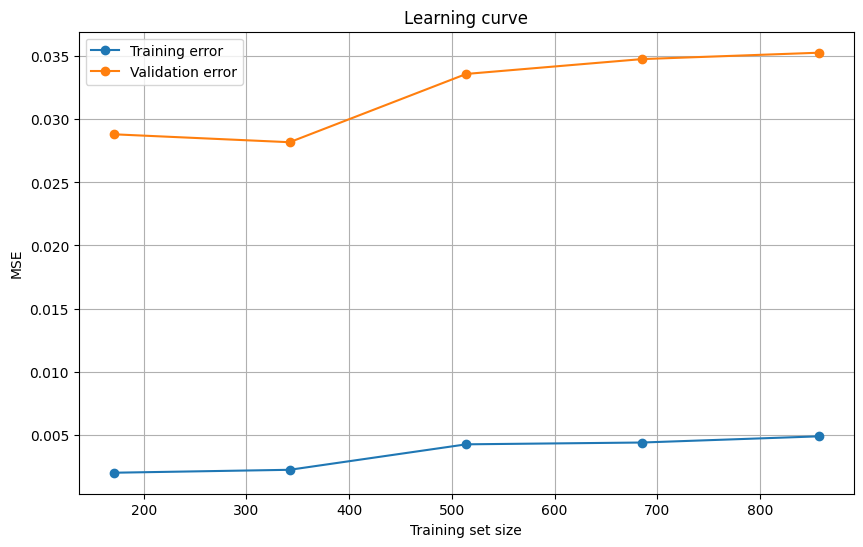

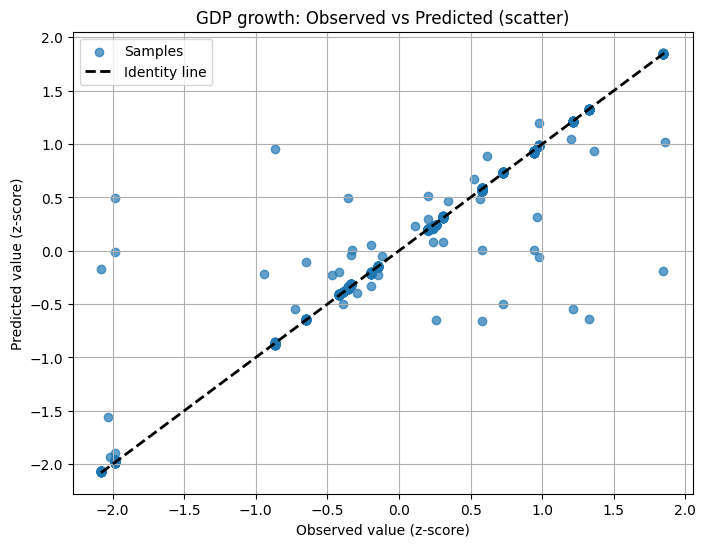

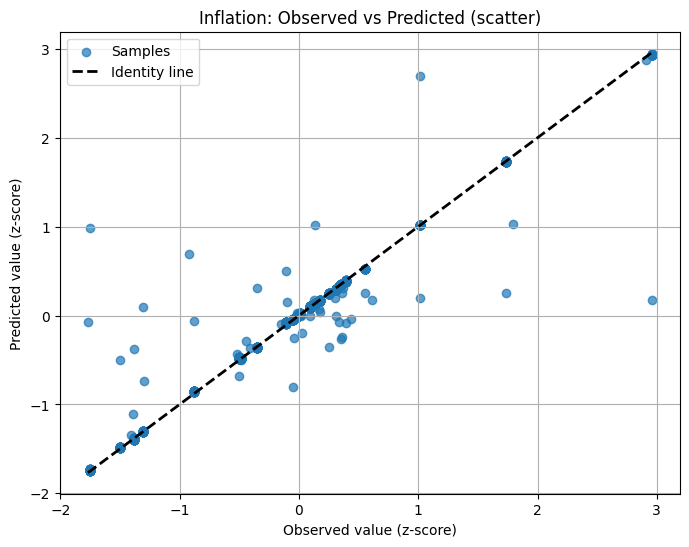

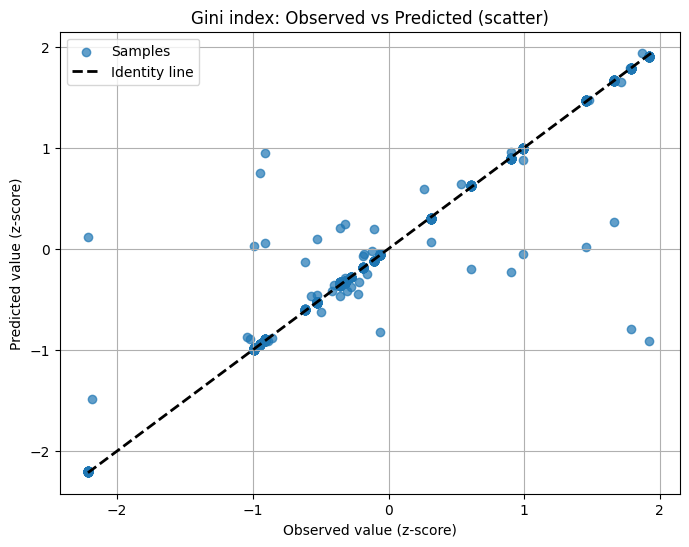


Modelo salvo em: saved_model.pkl


C:\Users\saulo\AppData\Local\Temp\ipykernel_85132\1535856587.py:548: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  X_syn = pd.concat([noisy_X, boot_X, vae_X], axis=0).reset_index(drop=True)
C:\Users\saulo\AppData\Local\Temp\ipykernel_85132\1535856587.py:549: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  y_syn = pd.concat([noisy_y, boot_y, vae_y], axis=0).reset_index(drop=True)
C:\Users\saulo\AppData\Local\Temp\ipykernel_85132\1535856587.py:548: FutureWarning: The behavior of DataFrame concatenat


Consolidated Metrics (CV on real folds with train-only synthetic — anti-leakage):
Mean General MSE: 1.0321547985076904
Mean General R²: -0.44522564113140106
--- GDP growth ---
Mean MSE: 1.104989048035185
Mean R²: -0.502270334662191
--- Inflation ---
Mean MSE: 1.7244472846393197
Mean R²: -1.4292730370636535
--- Gini index ---
Mean MSE: 0.267027991626845
Mean R²: 0.5958664972700507


In [1]:
# ================================================================
# Synthetic Augmentation + XGBoost (Multioutput)
# Avaliações:
#   (A) K-Fold no dataset aumentado (validação interna)
#   (B) CV em folds reais com sintético gerado só do treino do fold (anti-leakage)
# Saídas mantidas:
#   augmented_dataset.csv, comparison_table.csv, saved_model.pkl, graphs/*
# ================================================================

from __future__ import annotations

import os
import sys
import math
import random
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, Tuple, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, learning_curve
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.utils import resample
from sklearn.multioutput import MultiOutputRegressor

import joblib

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense
import tensorflow.keras.backend as K

from xgboost import XGBRegressor


# -----------------------------
# (0) Opcional: instalar pacotes
# -----------------------------
# !pip install -U numpy pandas matplotlib scikit-learn xgboost joblib tensorflow


# -----------------------------
# (1) Versões (sem quebrar no TF 2.15)
# -----------------------------
def safe_keras_version() -> str:
    # TF 2.15: tf.keras.__version__ não existe
    try:
        import keras  # keras standalone (pode ou não existir)
        return str(getattr(keras, "__version__", "unknown"))
    except Exception:
        try:
            return str(tf.keras.version())
        except Exception:
            return "unknown"


print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("TensorFlow:", tf.__version__)
print("Keras:", safe_keras_version())


# -----------------------------
# (2) Configuração
# -----------------------------
@dataclass(frozen=True)
class Config:
    seed: int = 42

    # Arquivos
    input_csv: str = "Processed_Normalized_Data.csv"
    augmented_csv: str = "augmented_dataset.csv"
    comparison_csv: str = "comparison_table.csv"
    model_pkl: str = "saved_model.pkl"

    # Pasta de gráficos
    graphs_dir: str = "graphs"

    # Sintético global (para dataset aumentado — validação interna)
    noise_scale_global: float = 0.05
    bootstrap_n_global: int = 1000
    use_vae_global: bool = True
    vae_latent_dim: int = 2
    vae_epochs: int = 80
    vae_batch_size: int = 16

    # CV
    n_splits: int = 5

    # Sintético por fold (anti-leakage)
    noise_scale_fold: float = 0.02
    bootstrap_n_fold: int = 200
    use_vae_fold: bool = False  # com N pequeno, VAE por fold tende a instabilidade

    # Pesos para evitar sintético dominar o treino
    w_real: float = 1.0
    w_syn: float = 0.15

    # XGBoost (conservador para N pequeno)
    xgb_params: Dict = None


def make_config() -> Config:
    params = dict(
        objective="reg:squarederror",
        n_estimators=900,
        learning_rate=0.02,
        max_depth=2,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=5.0,
        gamma=0.0,
        random_state=42,
        n_jobs=-1,
        tree_method="hist",
    )
    return Config(xgb_params=params)


CFG = make_config()


# -----------------------------
# (3) Utilitários
# -----------------------------
def set_seeds(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


def ensure_dirs(cfg: Config) -> None:
    Path(cfg.graphs_dir).mkdir(parents=True, exist_ok=True)


def load_data(cfg: Config) -> Tuple[pd.DataFrame, pd.DataFrame]:
    path = Path(cfg.input_csv)
    if not path.exists():
        raise FileNotFoundError(
            f"Não encontrei '{cfg.input_csv}' em: {Path.cwd()}\n"
            "Coloque o CSV no mesmo diretório do notebook ou ajuste Config.input_csv."
        )

    df = pd.read_csv(path)
    if df.shape[1] < 5:
        raise ValueError("CSV com poucas colunas. Verifique se é o arquivo correto.")

    # Convenção: 1ª coluna = índice/ano; últimas 3 = outputs
    X = df.iloc[:, 1:-3].copy()
    y = df.iloc[:, -3:].copy()

    if y.shape[1] != 3:
        raise ValueError("Esperado y com 3 colunas (3 variáveis-alvo).")

    return X, y


def add_gaussian_noise(arr: np.ndarray, noise_scale: float, rng: np.random.Generator) -> np.ndarray:
    noise = rng.normal(loc=0.0, scale=noise_scale, size=arr.shape)
    return arr + noise


def bootstrap_pairs(
    X: pd.DataFrame, y: pd.DataFrame, n_samples: int, rng_seed: int
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    Xb, yb = resample(X, y, n_samples=n_samples, random_state=rng_seed)
    if not isinstance(Xb, pd.DataFrame):
        Xb = pd.DataFrame(Xb, columns=X.columns)
    if not isinstance(yb, pd.DataFrame):
        yb = pd.DataFrame(yb, columns=y.columns)
    return Xb.reset_index(drop=True), yb.reset_index(drop=True)


# -----------------------------
# (4) VAE (reconstrução de X) — adequado a dados padronizados
# -----------------------------
class VAE(Model):
    """
    VAE simples para reconstrução.
    Ajuste para dados padronizados:
      - saída linear
      - loss de reconstrução por MSE (não BCE)
    """
    def __init__(self, input_dim: int, latent_dim: int = 2):
        super().__init__()
        self.enc_h = Dense(64, activation="relu")
        self.z_mean = Dense(latent_dim)
        self.z_log_var = Dense(latent_dim)
        self.dec_h = Dense(64, activation="relu")
        self.dec_out = Dense(input_dim, activation="linear")

    def encode(self, x):
        h = self.enc_h(x)
        return self.z_mean(h), self.z_log_var(h)

    def reparameterize(self, z_mean, z_log_var):
        eps = K.random_normal(shape=(tf.shape(z_mean)[0], tf.shape(z_mean)[1]))
        return z_mean + K.exp(0.5 * z_log_var) * eps

    def decode(self, z):
        h = self.dec_h(z)
        return self.dec_out(h)

    def call(self, inputs):
        z_mean, z_log_var = self.encode(inputs)
        z = self.reparameterize(z_mean, z_log_var)
        recon = self.decode(z)

        # Recon loss (MSE por amostra)
        recon_loss = K.mean(K.square(inputs - recon), axis=-1)

        # KL
        kl_loss = -0.5 * K.sum(
            1 + z_log_var - K.square(z_mean) - K.exp(z_log_var), axis=-1
        )

        self.add_loss(K.mean(recon_loss + kl_loss))
        return recon


def vae_reconstruct_X(X: pd.DataFrame, cfg: Config, seed: int) -> pd.DataFrame:
    set_seeds(seed)
    input_dim = X.shape[1]
    vae = VAE(input_dim=input_dim, latent_dim=cfg.vae_latent_dim)
    vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3))

    X_np = X.to_numpy(dtype=np.float32)

    vae.fit(
        X_np, X_np,
        epochs=cfg.vae_epochs,
        batch_size=cfg.vae_batch_size,
        shuffle=True,
        verbose=0
    )
    X_rec = vae.predict(X_np, verbose=0)
    return pd.DataFrame(X_rec, columns=X.columns)


# -----------------------------
# (5) Sintético global (para dataset aumentado — validação interna)
# -----------------------------
def generate_synthetic_global(
    X: pd.DataFrame, y: pd.DataFrame, cfg: Config
) -> Tuple[pd.DataFrame, pd.DataFrame]:

    rng = np.random.default_rng(cfg.seed)

    noisy_X = pd.DataFrame(
        add_gaussian_noise(X.to_numpy(), cfg.noise_scale_global, rng),
        columns=X.columns
    )
    noisy_y = pd.DataFrame(
        add_gaussian_noise(y.to_numpy(), cfg.noise_scale_global, rng),
        columns=y.columns
    )

    boot_X, boot_y = bootstrap_pairs(X, y, cfg.bootstrap_n_global, rng_seed=cfg.seed)

    if cfg.use_vae_global:
        vae_X = vae_reconstruct_X(X, cfg, seed=cfg.seed)
        vae_y = y.copy().reset_index(drop=True)
    else:
        vae_X = pd.DataFrame(columns=X.columns)
        vae_y = pd.DataFrame(columns=y.columns)

    synX = pd.concat([noisy_X, boot_X, vae_X], axis=0).reset_index(drop=True)
    synY = pd.concat([noisy_y, boot_y, vae_y], axis=0).reset_index(drop=True)
    return synX, synY


def build_augmented_dataset(
    X: pd.DataFrame, y: pd.DataFrame, synX: pd.DataFrame, synY: pd.DataFrame, cfg: Config
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:

    X_aug = pd.concat([X, synX], axis=0).reset_index(drop=True)
    y_aug = pd.concat([y, synY], axis=0).reset_index(drop=True)

    augmented = pd.concat([X_aug, y_aug], axis=1)
    augmented = augmented.sample(frac=1, random_state=cfg.seed).reset_index(drop=True)

    X_aug2 = augmented.iloc[:, :-y.shape[1]].copy()
    y_aug2 = augmented.iloc[:, -y.shape[1]:].copy()

    augmented.to_csv(cfg.augmented_csv, index=False)
    return X_aug2, y_aug2, augmented


# -----------------------------
# (6) Modelo XGBoost multioutput
# -----------------------------
def build_model(cfg: Config) -> MultiOutputRegressor:
    base = XGBRegressor(**cfg.xgb_params)
    return MultiOutputRegressor(base)


# -----------------------------
# (7) Métricas e plots
# -----------------------------
def compute_adjusted_r2(r2: float, n: int, p: int) -> float:
    denom = (n - p - 1)
    if denom <= 0:
        return float("nan")
    return 1.0 - (1.0 - r2) * (n - 1) / denom


def kfold_on_augmented(X_aug: pd.DataFrame, y_aug: pd.DataFrame, cfg: Config) -> Dict:
    kf = KFold(n_splits=cfg.n_splits, shuffle=True, random_state=cfg.seed)

    general_mse_list, general_r2_list, general_adj_r2_list = [], [], []
    detailed_metrics_list = []
    y_true_all, y_pred_all = [], []

    p = X_aug.shape[1]

    model_last = None

    for fold_idx, (tr, te) in enumerate(kf.split(X_aug), start=1):
        X_train, X_test = X_aug.iloc[tr], X_aug.iloc[te]
        y_train, y_test = y_aug.iloc[tr], y_aug.iloc[te]

        model = build_model(cfg)
        model.fit(X_train, y_train)
        model_last = model

        y_pred = model.predict(X_test)

        n_test = len(y_test)
        general_mse = mean_squared_error(y_test, y_pred)
        general_r2 = r2_score(y_test, y_pred)
        general_adj_r2 = compute_adjusted_r2(general_r2, n=n_test, p=p)

        general_mse_list.append(general_mse)
        general_r2_list.append(general_r2)
        general_adj_r2_list.append(general_adj_r2)

        detailed = {}
        for i, col in enumerate(y_aug.columns):
            mse_i = mean_squared_error(y_test[col], y_pred[:, i])
            rmse_i = math.sqrt(mse_i)
            r2_i = r2_score(y_test[col], y_pred[:, i])
            adj_i = compute_adjusted_r2(r2_i, n=n_test, p=p)
            sse_i = float(np.sum((y_test[col].to_numpy() - y_pred[:, i]) ** 2))
            detailed[col] = {"MSE": mse_i, "RMSE": rmse_i, "R²": r2_i, "Adjusted R²": adj_i, "SSE": sse_i}

        detailed_metrics_list.append(detailed)
        y_true_all.append(y_test.to_numpy())
        y_pred_all.append(y_pred)

    out = {
        "general_mse_mean": float(np.mean(general_mse_list)),
        "general_r2_mean": float(np.mean(general_r2_list)),
        "general_adj_r2_mean": float(np.nanmean(general_adj_r2_list)),
        "detailed_metrics_list": detailed_metrics_list,
        "y_true_all": np.concatenate(y_true_all, axis=0),
        "y_pred_all": np.concatenate(y_pred_all, axis=0),
        "model_last": model_last,
    }
    return out


def plot_and_save_true_vs_pred(y_true: np.ndarray, y_pred: np.ndarray, labels: List[str], cfg: Config) -> None:
    for i, label in enumerate(labels):
        plt.figure(figsize=(10, 6))
        plt.plot(range(len(y_true)), y_true[:, i], label=f"Observed {label}", marker="o")
        plt.plot(range(len(y_true)), y_pred[:, i], label=f"Predicted {label}", marker="x")
        plt.legend()
        plt.title(f"{label} - Observed vs Predicted")
        plt.xlabel("Samples")
        plt.ylabel(f"Standardised value (z-score)")
        plt.grid(True)
        plt.savefig(Path(cfg.graphs_dir) / f"{label.replace(' ', '_').lower()}_comparison.png")
        plt.show()
        plt.close()


def plot_and_save_scatter(y_true: np.ndarray, y_pred: np.ndarray, labels: List[str], cfg: Config) -> None:
    for i, label in enumerate(labels):
        plt.figure(figsize=(8, 6))
        plt.scatter(y_true[:, i], y_pred[:, i], alpha=0.7, label="Samples")
        lim_inf = float(min(y_true[:, i].min(), y_pred[:, i].min()))
        lim_sup = float(max(y_true[:, i].max(), y_pred[:, i].max()))
        plt.plot([lim_inf, lim_sup], [lim_inf, lim_sup], "k--", lw=2, label="Identity line")
        plt.xlabel("Observed value (z-score)")
        plt.ylabel("Predicted value (z-score)")
        plt.title(f"{label}: Observed vs Predicted (scatter)")
        plt.legend()
        plt.grid(True)
        plt.savefig(Path(cfg.graphs_dir) / f"scatter_comparison_{label.replace(' ', '_').lower()}.png")
        plt.show()
        plt.close()


def plot_and_save_learning_curve(estimator, X: pd.DataFrame, y: pd.DataFrame, cfg: Config) -> None:
    train_sizes, train_scores, val_scores = learning_curve(
        estimator=estimator,
        X=X,
        y=y,
        cv=cfg.n_splits,
        train_sizes=np.linspace(0.2, 1.0, 5),
        scoring="neg_mean_squared_error",
        n_jobs=-1,
    )
    train_scores_mean = -np.mean(train_scores, axis=1)
    val_scores_mean = -np.mean(val_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_scores_mean, label="Training error", marker="o")
    plt.plot(train_sizes, val_scores_mean, label="Validation error", marker="o")
    plt.xlabel("Training set size")
    plt.ylabel("MSE")
    plt.title("Learning curve")
    plt.legend()
    plt.grid(True)
    plt.savefig(Path(cfg.graphs_dir) / "learning_curve.png")
    plt.show()
    plt.close()


def save_comparison_table(y_true: np.ndarray, y_pred: np.ndarray, labels: List[str], cfg: Config) -> None:
    comparison_df = pd.DataFrame(y_true, columns=[f"Observed {lab}" for lab in labels])
    for j, label in enumerate(labels):
        comparison_df[f"Predicted {label}"] = y_pred[:, j]

    print("Comparison Table - primeiras 5 observações:")
    print(comparison_df.head())
    print("\nComparison Table - últimas 5 observações:")
    print(comparison_df.tail())

    comparison_df.to_csv(cfg.comparison_csv, index=False)


def save_descriptive_stats_and_distributions(
    X: pd.DataFrame, synX: pd.DataFrame, y: pd.DataFrame, synY: pd.DataFrame, cfg: Config
) -> None:
    stats_original_X = X.describe().loc[["mean", "std", "min", "max"]]
    stats_synthetic_X = synX.describe().loc[["mean", "std", "min", "max"]]
    stats_original_y = y.describe().loc[["mean", "std", "min", "max"]]
    stats_synthetic_y = synY.describe().loc[["mean", "std", "min", "max"]]

    print("Statistics of original data (inputs):")
    print(stats_original_X)
    print("\nStatistics of synthetic data (inputs):")
    print(stats_synthetic_X)

    print("\nStatistics of original data (outputs):")
    print(stats_original_y)
    print("\nStatistics of synthetic data (outputs):")
    print(stats_synthetic_y)

    stats_original_X.to_csv("original_inputs_descriptive_stats.csv")
    stats_synthetic_X.to_csv("synthetic_inputs_descriptive_stats.csv")
    stats_original_y.to_csv("original_outputs_descriptive_stats.csv")
    stats_synthetic_y.to_csv("synthetic_outputs_descriptive_stats.csv")

    # Boxplots e histogramas
    for col in X.columns:
        plt.figure(figsize=(8, 6))
        plt.boxplot([X[col], synX[col]], labels=["Original", "Synthetic"])
        plt.title(f"Distribution comparison (z-score) - {col}")
        plt.ylabel("Standardised value (z-score)")
        plt.grid(True)
        plt.savefig(Path(cfg.graphs_dir) / f"boxplot_{col}.png")
        plt.close()

        plt.figure(figsize=(8, 6))
        plt.hist(X[col], bins=20, alpha=0.5, label="Original")
        plt.hist(synX[col], bins=20, alpha=0.5, label="Synthetic")
        plt.xlabel("Standardised value (z-score)")
        plt.ylabel("Frequency")
        plt.title(f"Comparative histogram (z-score) - {col}")
        plt.legend()
        plt.grid(True)
        plt.savefig(Path(cfg.graphs_dir) / f"histogram_{col}.png")
        plt.close()

    for col in y.columns:
        plt.figure(figsize=(8, 6))
        plt.boxplot([y[col], synY[col]], labels=["Original", "Synthetic"])
        plt.title(f"Distribution comparison (z-score) - {col}")
        plt.ylabel("Standardised value (z-score)")
        plt.grid(True)
        plt.savefig(Path(cfg.graphs_dir) / f"boxplot_{col}.png")
        plt.close()

        plt.figure(figsize=(8, 6))
        plt.hist(y[col], bins=20, alpha=0.5, label="Original")
        plt.hist(synY[col], bins=20, alpha=0.5, label="Synthetic")
        plt.xlabel("Standardised value (z-score)")
        plt.ylabel("Frequency")
        plt.title(f"Comparative histogram (z-score) - {col}")
        plt.legend()
        plt.grid(True)
        plt.savefig(Path(cfg.graphs_dir) / f"histogram_{col}.png")
        plt.close()

    print("Number of original observations:", X.shape[0])
    print("Number of synthetic observations:", synX.shape[0])
    print("Final number of observations after concatenation:", X.shape[0] + synX.shape[0])


# -----------------------------
# (8) CV anti-leakage: folds reais; sintético só do treino do fold
# -----------------------------
def generate_fold_synthetics_from_train(
    X_train_real: pd.DataFrame,
    y_train_real: pd.DataFrame,
    cfg: Config,
    fold_seed: int,
) -> Tuple[pd.DataFrame, pd.DataFrame]:

    rng = np.random.default_rng(fold_seed)

    noisy_X = pd.DataFrame(
        add_gaussian_noise(X_train_real.to_numpy(), cfg.noise_scale_fold, rng),
        columns=X_train_real.columns,
    )
    noisy_y = pd.DataFrame(
        add_gaussian_noise(y_train_real.to_numpy(), cfg.noise_scale_fold, rng),
        columns=y_train_real.columns,
    )

    boot_X, boot_y = bootstrap_pairs(
        X_train_real, y_train_real,
        n_samples=cfg.bootstrap_n_fold,
        rng_seed=fold_seed
    )

    if cfg.use_vae_fold:
        try:
            vae_X = vae_reconstruct_X(X_train_real, cfg, seed=fold_seed)
            vae_y = y_train_real.copy().reset_index(drop=True)
        except Exception as e:
            print("Aviso: VAE fold-wise falhou; seguindo sem VAE no fold. Erro:", repr(e))
            vae_X = pd.DataFrame(columns=X_train_real.columns)
            vae_y = pd.DataFrame(columns=y_train_real.columns)
    else:
        vae_X = pd.DataFrame(columns=X_train_real.columns)
        vae_y = pd.DataFrame(columns=y_train_real.columns)

    X_syn = pd.concat([noisy_X, boot_X, vae_X], axis=0).reset_index(drop=True)
    y_syn = pd.concat([noisy_y, boot_y, vae_y], axis=0).reset_index(drop=True)
    return X_syn, y_syn


def cv_real_folds_with_train_only_synthetic(X_real: pd.DataFrame, y_real: pd.DataFrame, cfg: Config) -> Dict:
    kf = KFold(n_splits=cfg.n_splits, shuffle=True, random_state=cfg.seed)

    mse_list, r2_list = [], []
    per_target = {col: {"mse": [], "r2": []} for col in y_real.columns}

    for fold_idx, (tr, te) in enumerate(kf.split(X_real), start=1):
        fold_seed = cfg.seed + 10_000 * fold_idx

        X_train_real = X_real.iloc[tr].copy()
        y_train_real = y_real.iloc[tr].copy()
        X_test_real = X_real.iloc[te].copy()
        y_test_real = y_real.iloc[te].copy()

        X_syn, y_syn = generate_fold_synthetics_from_train(X_train_real, y_train_real, cfg, fold_seed=fold_seed)

        X_train = pd.concat([X_train_real, X_syn], axis=0).reset_index(drop=True)
        y_train = pd.concat([y_train_real, y_syn], axis=0).reset_index(drop=True)

        w = np.concatenate(
            [
                np.full(len(X_train_real), cfg.w_real, dtype=float),
                np.full(len(X_syn), cfg.w_syn, dtype=float),
            ]
        )

        model = build_model(cfg)
        model.fit(X_train, y_train, sample_weight=w)

        y_pred = model.predict(X_test_real)

        mse = mean_squared_error(y_test_real, y_pred)
        r2 = r2_score(y_test_real, y_pred)

        mse_list.append(mse)
        r2_list.append(r2)

        for i, col in enumerate(y_real.columns):
            per_target[col]["mse"].append(mean_squared_error(y_test_real[col], y_pred[:, i]))
            per_target[col]["r2"].append(r2_score(y_test_real[col], y_pred[:, i]))

    out = {
        "mse_mean": float(np.mean(mse_list)),
        "r2_mean": float(np.mean(r2_list)),
        "per_target": {
            col: {
                "mse_mean": float(np.mean(v["mse"])),
                "r2_mean": float(np.mean(v["r2"])),
            }
            for col, v in per_target.items()
        },
    }
    return out


# -----------------------------
# (9) Execução principal
# -----------------------------
def main(cfg: Config) -> None:
    set_seeds(cfg.seed)
    ensure_dirs(cfg)

    X, y = load_data(cfg)

    # Labels para gráficos e tabela
    labels = [str(c) for c in y.columns]

    # ---- Sintético global + dataset aumentado (validação interna)
    synX, synY = generate_synthetic_global(X, y, cfg)
    X_aug, y_aug, _ = build_augmented_dataset(X, y, synX, synY, cfg)

    save_descriptive_stats_and_distributions(X, synX, y, synY, cfg)

    # ---- (A) K-Fold no dataset aumentado
    res_aug = kfold_on_augmented(X_aug, y_aug, cfg)

    print("\nConsolidated Metrics (K-Fold on augmented dataset — internal validation):")
    print(f"Mean General MSE: {res_aug['general_mse_mean']}")
    print(f"Mean General R²: {res_aug['general_r2_mean']}")
    print(f"Mean General Adjusted R²: {res_aug['general_adj_r2_mean']}")

    detailed_list = res_aug["detailed_metrics_list"]
    for col in y.columns:
        mse_mean = float(np.mean([m[col]["MSE"] for m in detailed_list]))
        rmse_mean = float(np.mean([m[col]["RMSE"] for m in detailed_list]))
        r2_mean = float(np.mean([m[col]["R²"] for m in detailed_list]))
        adj_mean = float(np.nanmean([m[col]["Adjusted R²"] for m in detailed_list]))
        print(f"--- {col} Metrics ---")
        print(f"Mean MSE: {mse_mean}")
        print(f"Mean RMSE: {rmse_mean}")
        print(f"Mean R²: {r2_mean}")
        print(f"Mean Adjusted R²: {adj_mean}")

    y_true_all = res_aug["y_true_all"]
    y_pred_all = res_aug["y_pred_all"]

    plot_and_save_true_vs_pred(y_true_all, y_pred_all, labels, cfg)
    save_comparison_table(y_true_all, y_pred_all, labels, cfg)
    plot_and_save_learning_curve(build_model(cfg), X_aug, y_aug, cfg)
    plot_and_save_scatter(y_true_all, y_pred_all, labels, cfg)

    joblib.dump(res_aug["model_last"], cfg.model_pkl)
    print(f"\nModelo salvo em: {cfg.model_pkl}")

    # ---- (B) CV anti-leakage (folds reais; sintético só do treino)
    res_safe = cv_real_folds_with_train_only_synthetic(X, y, cfg)

    print("\nConsolidated Metrics (CV on real folds with train-only synthetic — anti-leakage):")
    print(f"Mean General MSE: {res_safe['mse_mean']}")
    print(f"Mean General R²: {res_safe['r2_mean']}")
    for col, v in res_safe["per_target"].items():
        print(f"--- {col} ---")
        print(f"Mean MSE: {v['mse_mean']}")
        print(f"Mean R²: {v['r2_mean']}")


# -----------------------------
# (10) Rodar
# -----------------------------
main(CFG)
